INITIALIZE & TRAIN:

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
# Import from organized wind_farm_control package
from wind_farm_control.environments import FlorisMultiAgentEnv
from wind_farm_control.models import Actor, Critic
from wind_farm_control.training import train_mappo

from skrl.envs.wrappers.torch import wrap_env
from skrl.memories.torch import RandomMemory
from skrl.multi_agents.torch.mappo import MAPPO, MAPPO_DEFAULT_CONFIG
from skrl.trainers.torch import SequentialTrainer

# Env Setup
raw_env = FlorisMultiAgentEnv("../data_generation/farm_types/gch.yaml")
env = wrap_env(raw_env, wrapper="pettingzoo")

# memory object
memory = RandomMemory(memory_size=2000, num_envs=env.num_envs, device=env.device)

# wrapped in a dictionary for MAPPO
memories = {agent_name: memory for agent_name in env.possible_agents}

# Model Sharing (Corrected spaces)
shared_policy = Actor(
    env.observation_spaces["turbine_0"], env.action_spaces["turbine_0"], env.device
)

# Ensure the Critic uses the SHARED space (the 12-element one)
shared_value = Critic(
    env.shared_observation_spaces["turbine_0"],
    env.action_spaces["turbine_0"],
    env.device,
)

models = {
    a: {"policy": shared_policy, "value": shared_value} for a in env.possible_agents
}

# MAPPO Config Fix: Add 'state_shape' if using custom memory
cfg_agent = MAPPO_DEFAULT_CONFIG.copy()
cfg_agent["random_timesteps"] = 0  # Start learning immediately
cfg_agent["learning_rate"] = 5e-4
cfg_agent["state_preprocessor"] = None  # Optional: helps with stability

# 3. Pass the DICTIONARY to the agent
agent = MAPPO(
    possible_agents=env.possible_agents,
    models=models,
    memories=memories,
    cfg=cfg_agent,
    observation_spaces=env.observation_spaces,
    action_spaces=env.action_spaces,
    device=env.device,
    shared_observation_spaces=env.shared_observation_spaces,
)

# TRAIN
trainer = SequentialTrainer(
    env=env,
    agents=agent,
    cfg={"timesteps": 5000, "headless": True, "disable_progressbar": False},
)
trainer.train()

[skrl:INFO] Environment wrapper: Petting Zoo


100%|██████████| 5000/5000 [05:17<00:00, 15.74it/s]


EVALUATE

Starting MAPPO Evaluation over 20 episodes...


/home/nandan/SourceCode/wind-farm-control/.venv/lib/python3.13/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(


Evaluation Complete.
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Gain_%, dtype: float64


ValueError: List of boxplot statistics and `positions` values must have same the length

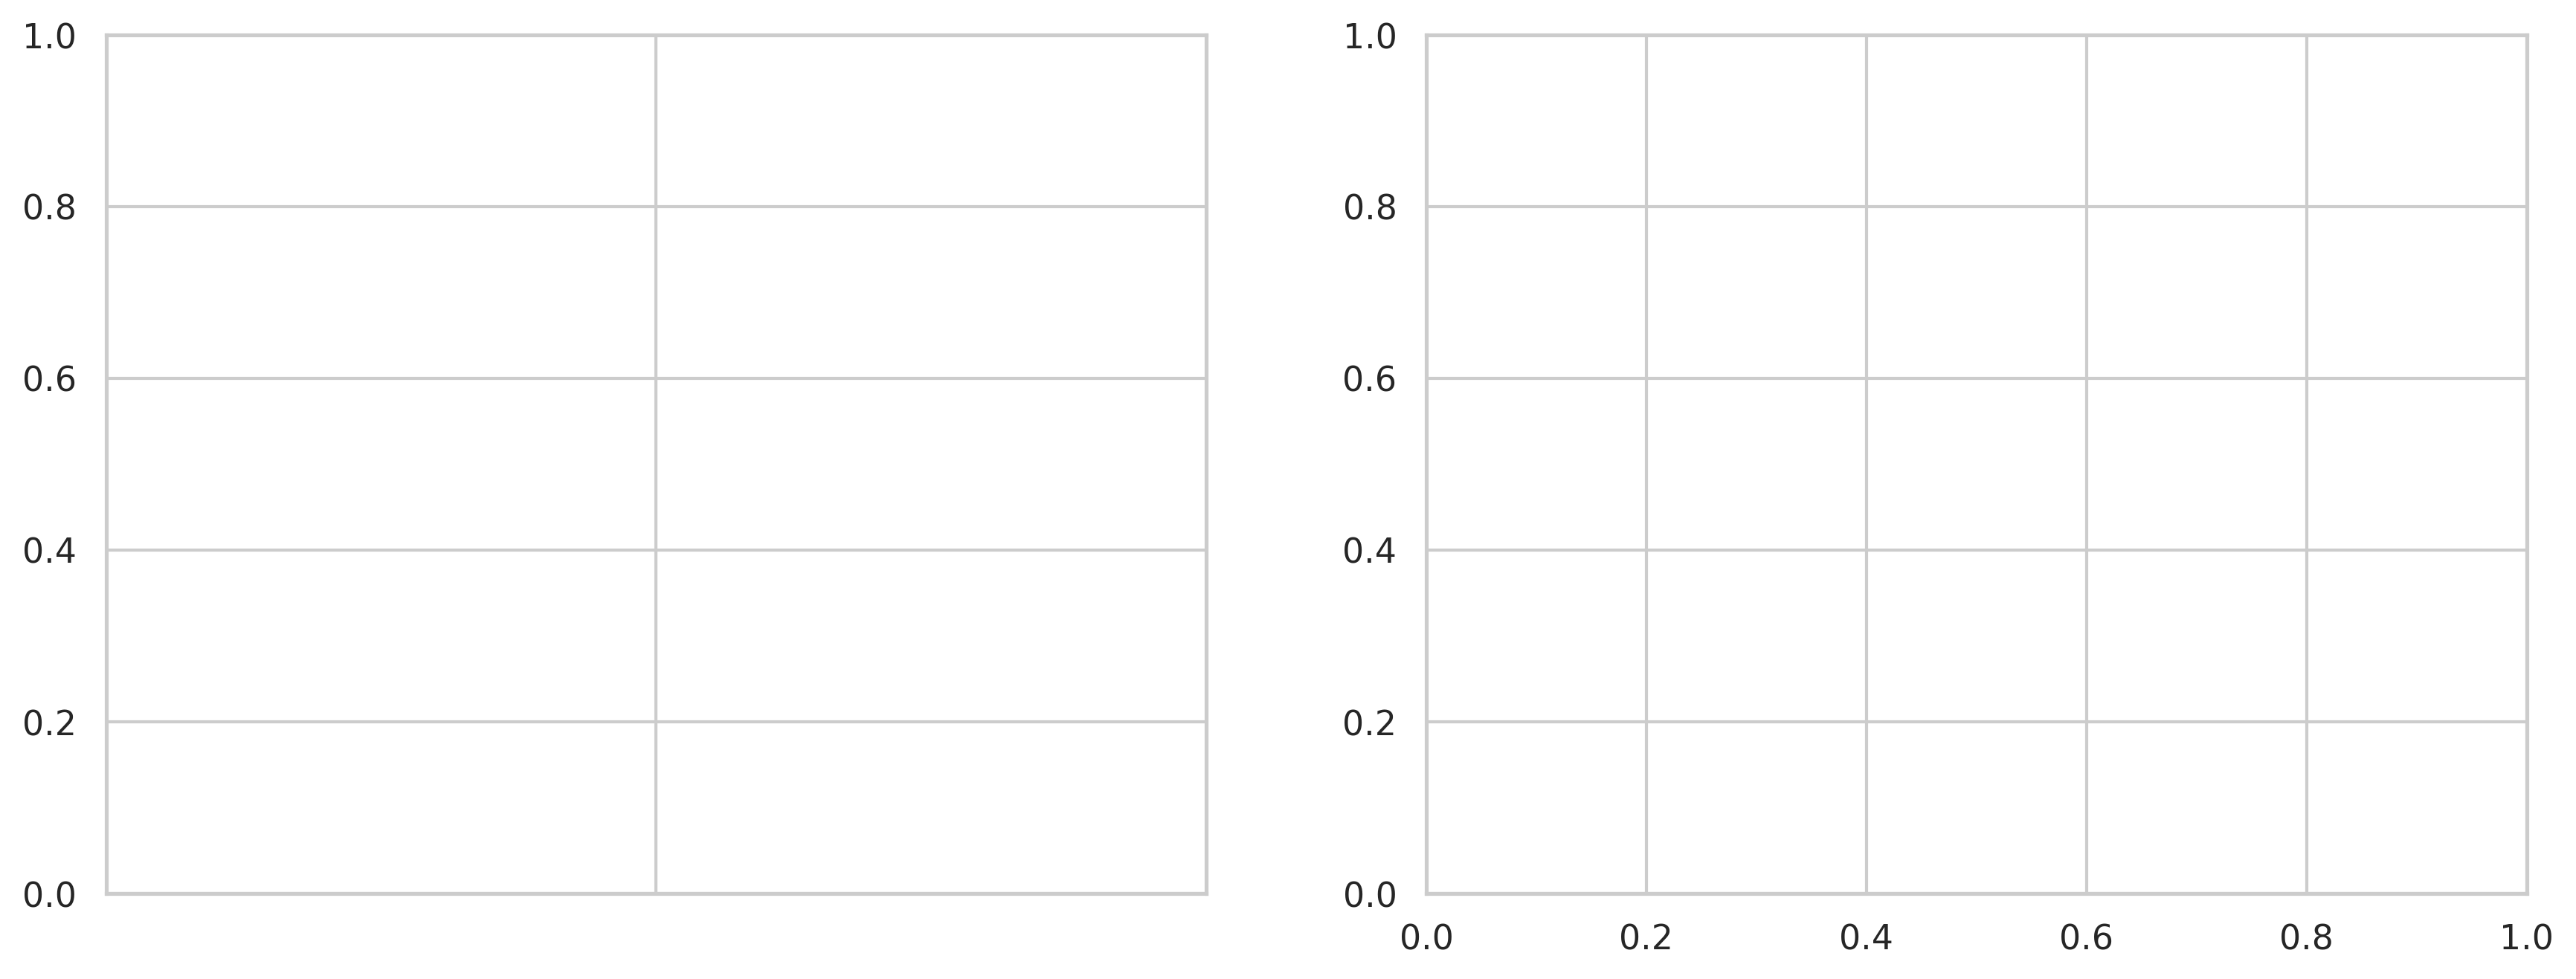

In [6]:
# Import evaluation utilities
from wind_farm_control.evaluation import (
    evaluate_mappo_vs_baseline,
    plot_mappo_performance,
)

# Execute evaluation
df_mappo_results = evaluate_mappo_vs_baseline(agent, env, n_episodes=20)
print(df_mappo_results["Gain_%"].describe())
plot_mappo_performance(df_mappo_results)

HYPERPARAMETER TUNING

In [ ]:
# Import hyperparameter tuning utilities
from wind_farm_control.utils import run_hyperparameter_tuning

# Run hyperparameter tuning
study = run_hyperparameter_tuning(
    config_path="../data_generation/farm_types/gch.yaml",
    n_trials=10,
    training_timesteps=5000,
    eval_steps=100,
)